# Credit Card Customer Segmentation

**Dataset:** Credit Card Dataset for Clustering  
**Rows:** 8,950 active credit card holders  
**Columns:** 18  
**Clustering Features:** 17 after removing `CUST_ID`  

**Goal:** Identify distinct customer segments to inform targeted marketing strategies.

---
### Notebook Structure
1. Imports & Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Data Cleaning & Preparation  
4. Feature Scaling  
5. Hierarchical Clustering (Agglomerative)  
6. K-Means Clustering: Elbow & Silhouette Methods  
7. Final Model & Cluster Visualisation  
8. Cluster Profiling & Interpretation

---

## **Import Necessary Libraries for EDA**

In [1]:
# Import Necessary Libraries for EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %pip install --quiet scikit-learn scipy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import scipy.cluster.hierarchy as shc

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---

## 1. Import Data

In [2]:
# Import the dataset, ensuring compatibility with the selected data analysis tools and libraries.
data = pd.read_csv("../data/Credit_card_dataset.csv")

In [3]:
# Check if the file has headers or comments
data.head()
# data.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Check basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# Check column names and ensure they're correct
data.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [6]:
# Check shape of the data
data.shape

(8950, 18)

---

## 2. Exploratory Data Analysis (EDA)

In [7]:
# Summary statistics
data.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.138560
BALANCE_FREQUENCY,8950.000000,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.000000
CASH_ADVANCE,8950.000000,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.211760
PURCHASES_FREQUENCY,8950.000000,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.500000


In [8]:
# Detect and handle missing data:
# Identify missing values across features and employ appropriate strategies (imputation, deletion, or interpolation)

missing = data.isnull().sum()
missing_values = missing[missing > 0]

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


<Figure size 1800x1400 with 0 Axes>

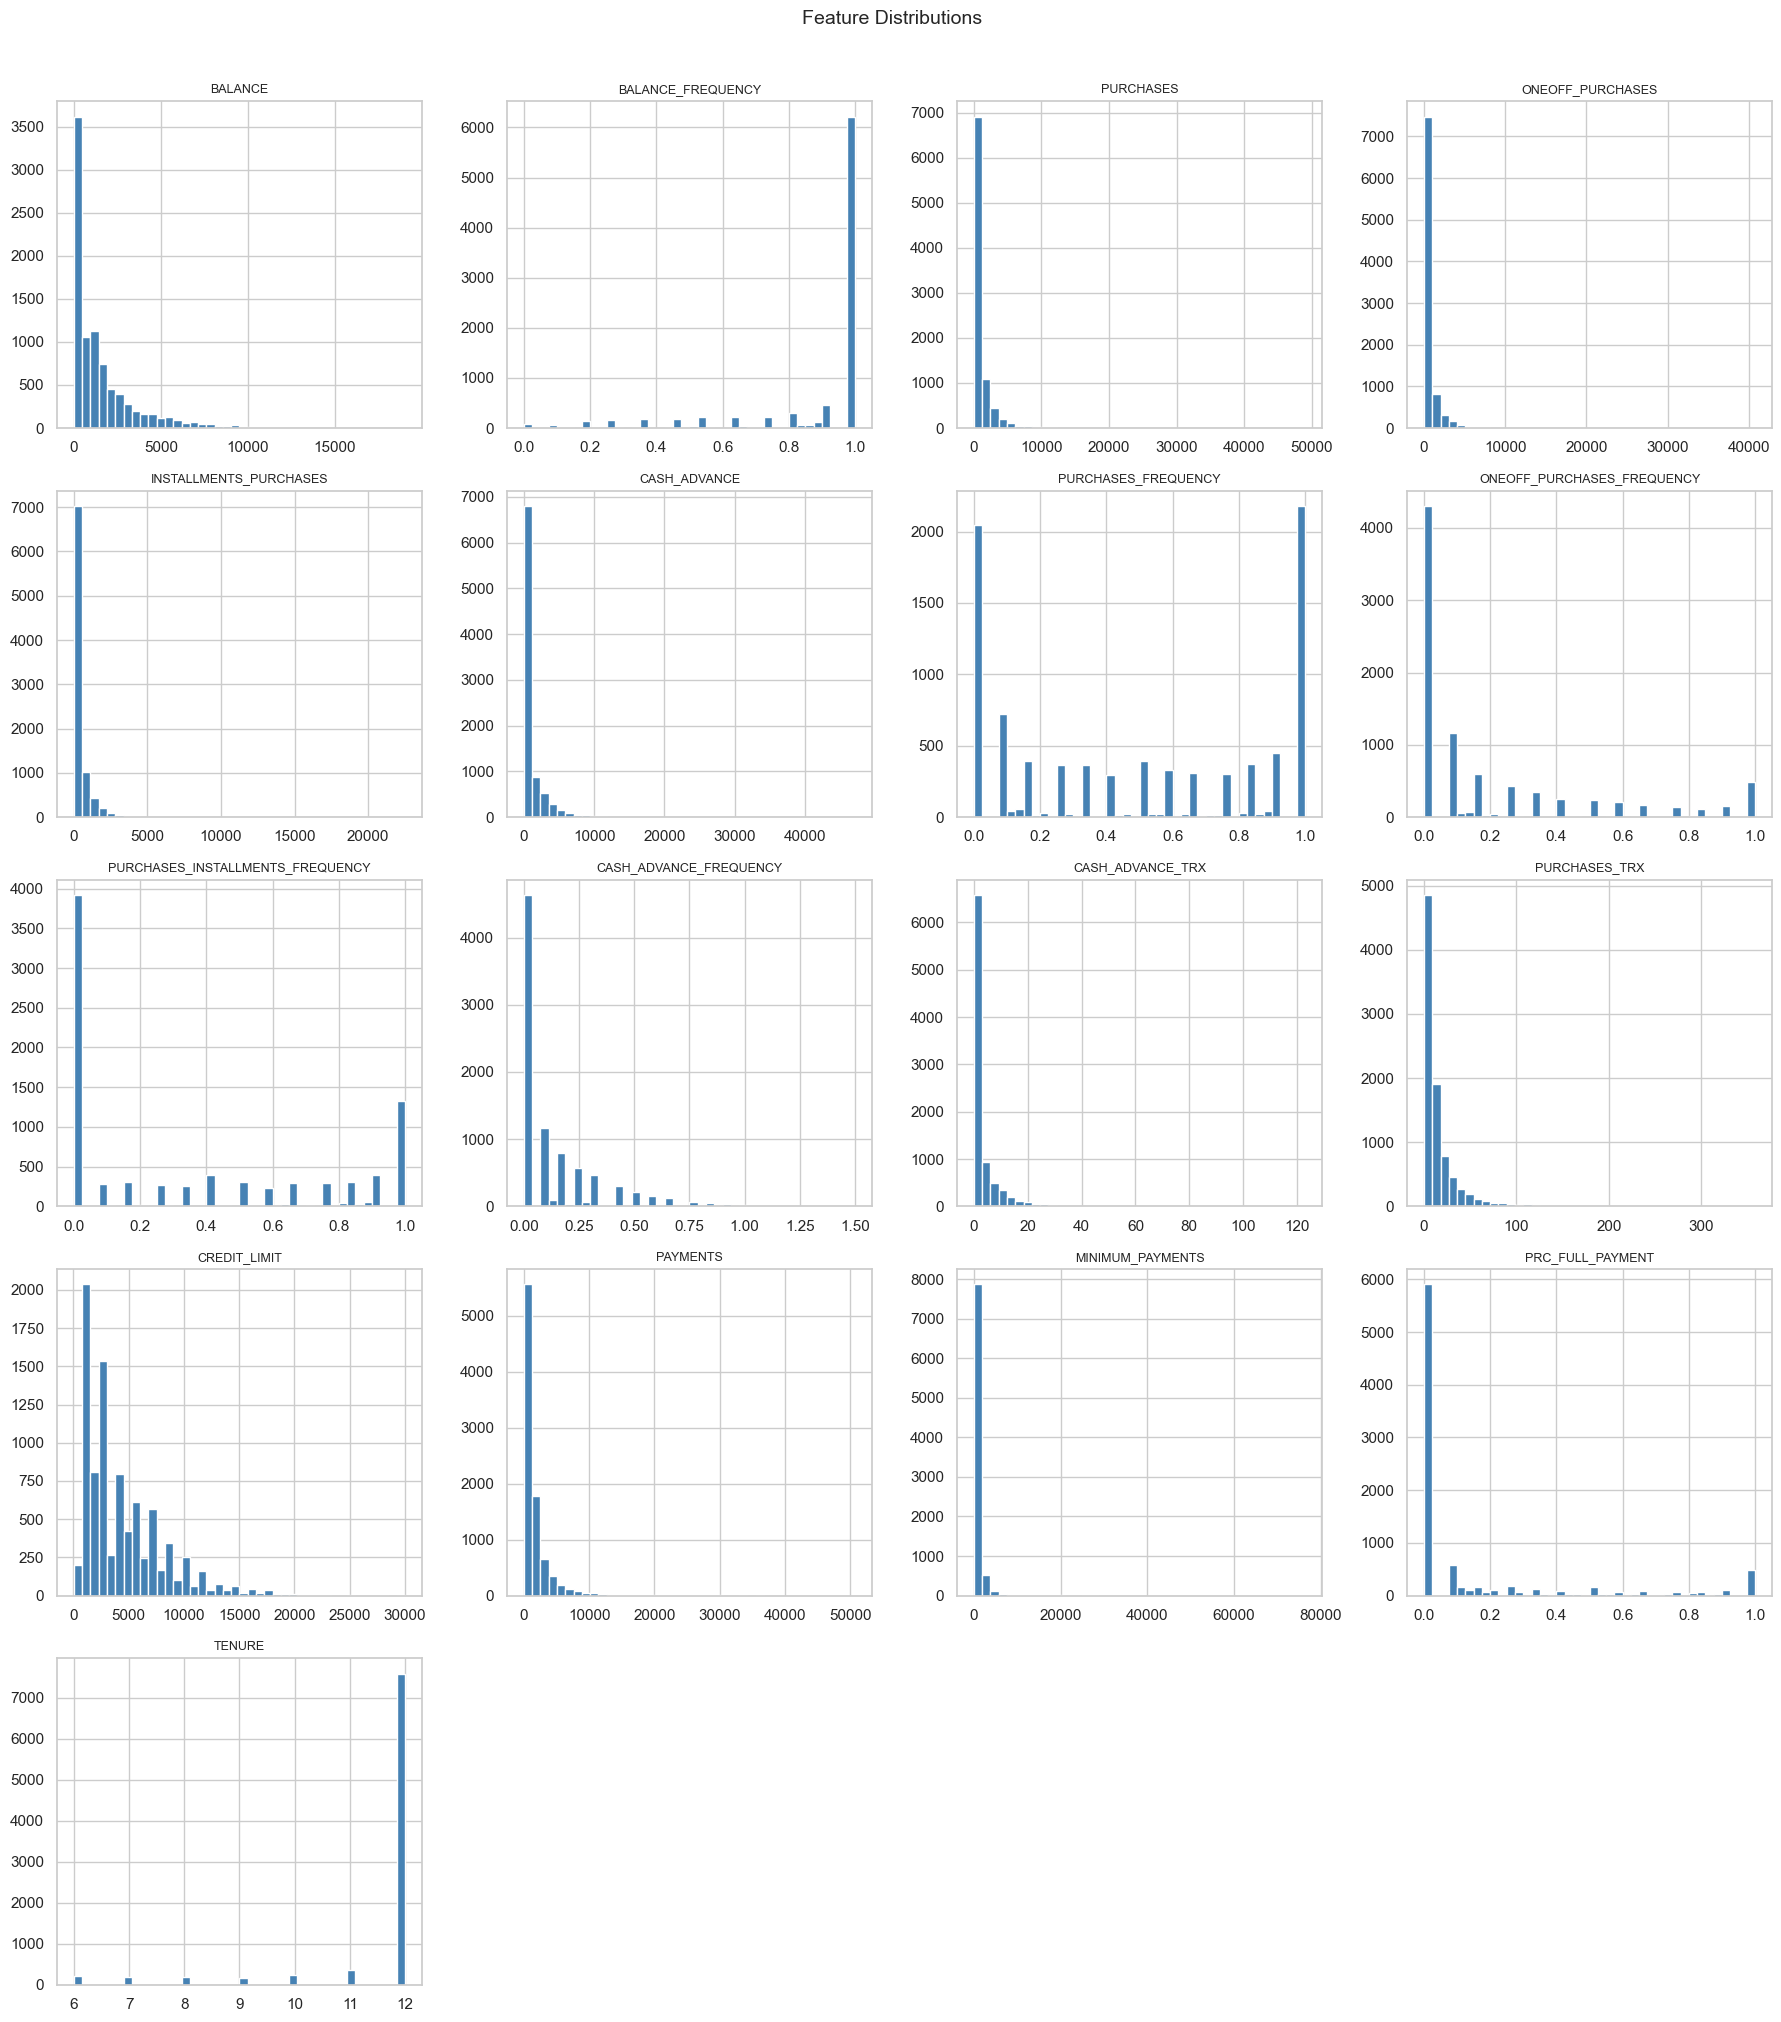

In [9]:
# Distribution of key numeric features
numeric_cols = data.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i == 0 and len(numeric_cols) > len(axes):
        rows = int(np.ceil(len(numeric_cols) / 4))
        fig.clf()
        fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(18, 4 * rows))
        axes = axes.flatten()
    axes[i].hist(data[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

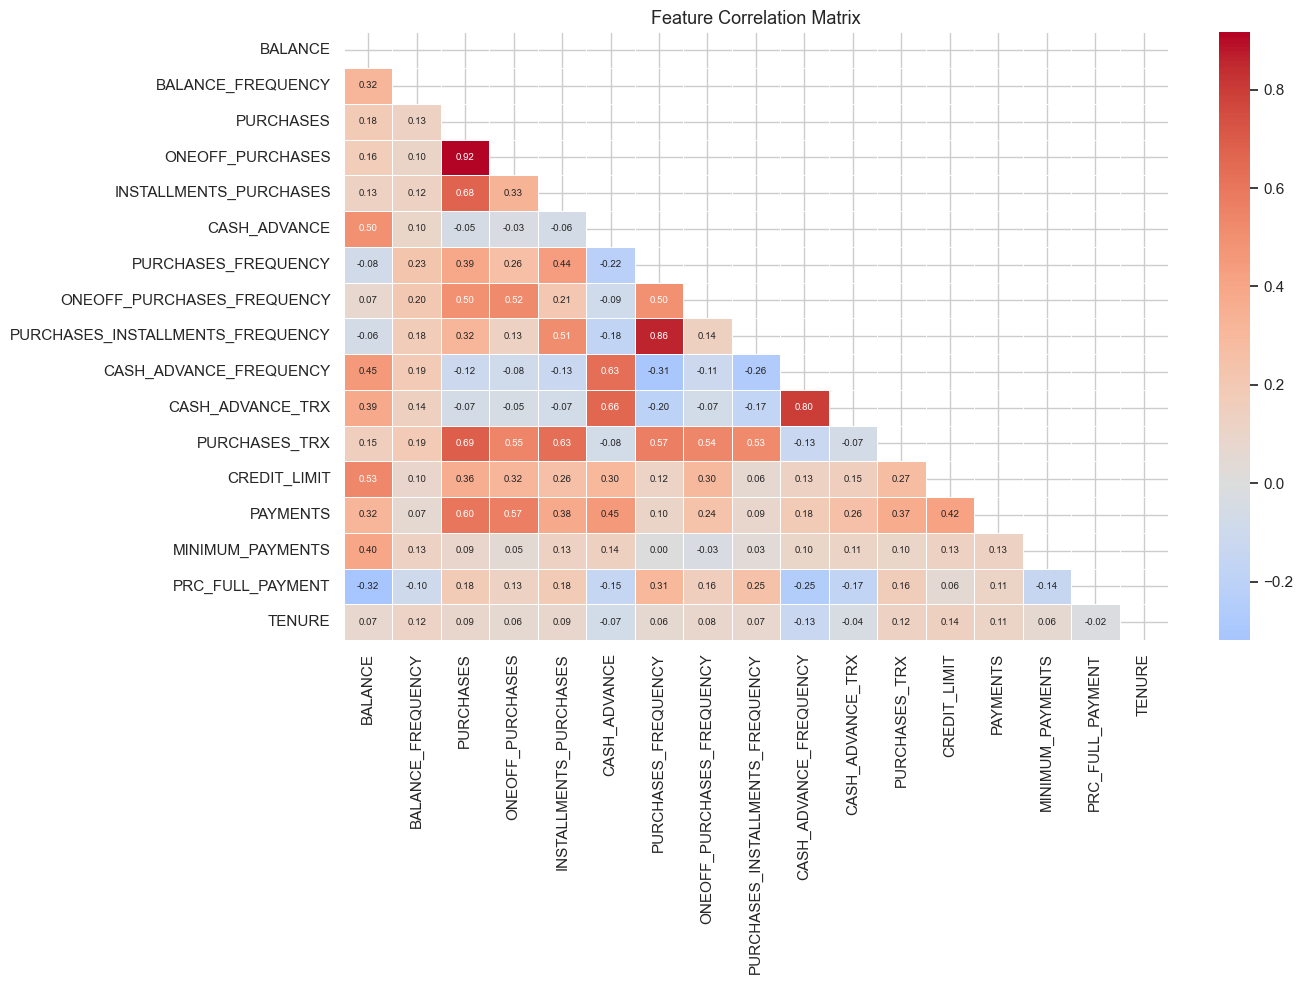

In [10]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = data[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 7}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# PURCHASES zero count, is zero a valid value?
zero_purchases = (data['PURCHASES'] == 0).sum()
print(f'Customers with PURCHASES == 0 : {zero_purchases} '
      f'({zero_purchases/len(data)*100:.1f}%)')
print('\nNote: Zero purchases is a valid, meaningful data point.\n'
      'These customers have made no purchases in the 6-month period.\n'
      'We do not replace these zeros with the column mean.')

Customers with PURCHASES == 0 : 2044 (22.8%)

Note: Zero purchases is a valid, meaningful data point.
These customers have made no purchases in the 6-month period.
We do not replace these zeros with the column mean.


---

## 3. Data Cleaning & Preparation

In [12]:
# Work on a copy so raw data stays intact
df = data.copy()

# Impute with median (more robust than mean for right-skewed columns)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

# Verify no missing values remain
print('Missing values after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('None found.' if df.isnull().sum().sum() == 0 else '')

Missing values after imputation:
Series([], dtype: int64)
None found.


In [13]:
# Check for duplicated data: Identify and remove duplicate entries to avoid redundancy in the dataset.

n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Dropped {n_dupes} duplicates. New shape: {df.shape}')

Duplicate rows: 0


In [14]:
# Ensure correct data types: Verify that each feature has the correct data type for accurate analysis.

print(df.dtypes)
df.head()

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [15]:
# Validate data: Scrutinize the data for validity, ensuring that rows and columns convey the intended information.

# Assuming 'data' is your DataFrame
cols = data.columns

# Iterate through columns and print unique values
for col in cols:
    if data[col].nunique() <= 20:
        print(f"Column: {col} → {data[col].unique()}")

Column: TENURE → [12  8 11  9 10  7  6]


In [16]:
# Feature Selection
# Drop CUST_ID (identifier, not a feature).
# Retain all behavioural features: we let the clustering decide what matters.

drop_cols = ['CUST_ID']
data_main = df.drop(columns=drop_cols)

print(f'Features used for clustering ({len(data_main.columns)}):')
print(data_main.columns.tolist())

Features used for clustering (17):
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


---
## 4. Feature Scaling

**Why scaling is mandatory for distance-based clustering:**  
- K-Means and Hierarchical clustering compute Euclidean distances.  
- Without scaling, `CREDIT_LIMIT` (range 50–30,000) will completely dominate  
- `TENURE` (range 6–12), making the latter virtually invisible to the algorithm.  
- `StandardScaler` brings every feature to zero mean and unit variance.

In [17]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_main)
data_scaled_df = pd.DataFrame(data_scaled, columns=data_main.columns)

print('Scaled data: mean and std (should be ~0 and ~1):')
print(data_scaled_df.describe().loc[['mean', 'std']].round(4))

Scaled data: mean and std (should be ~0 and ~1):
      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
mean  -0.0000             0.0000     0.0000           -0.0000   
std    1.0001             1.0001     1.0001            1.0001   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
mean                  0.0000       -0.0000               0.0000   
std                   1.0001        1.0001               1.0001   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
mean                      0.0000                            0.0000   
std                       1.0001                            1.0001   

      CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  \
mean                 -0.0000           -0.0000        -0.0000        0.0000   
std                   1.0001            1.0001         1.0001        1.0001   

      PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE  
mean   -0.0000            0.0000           

---
## 5. Hierarchical Clustering (Agglomerative)

We first draw a dendrogram on a sample of the data (full 8,950-row linkage is slow and visually unreadable).

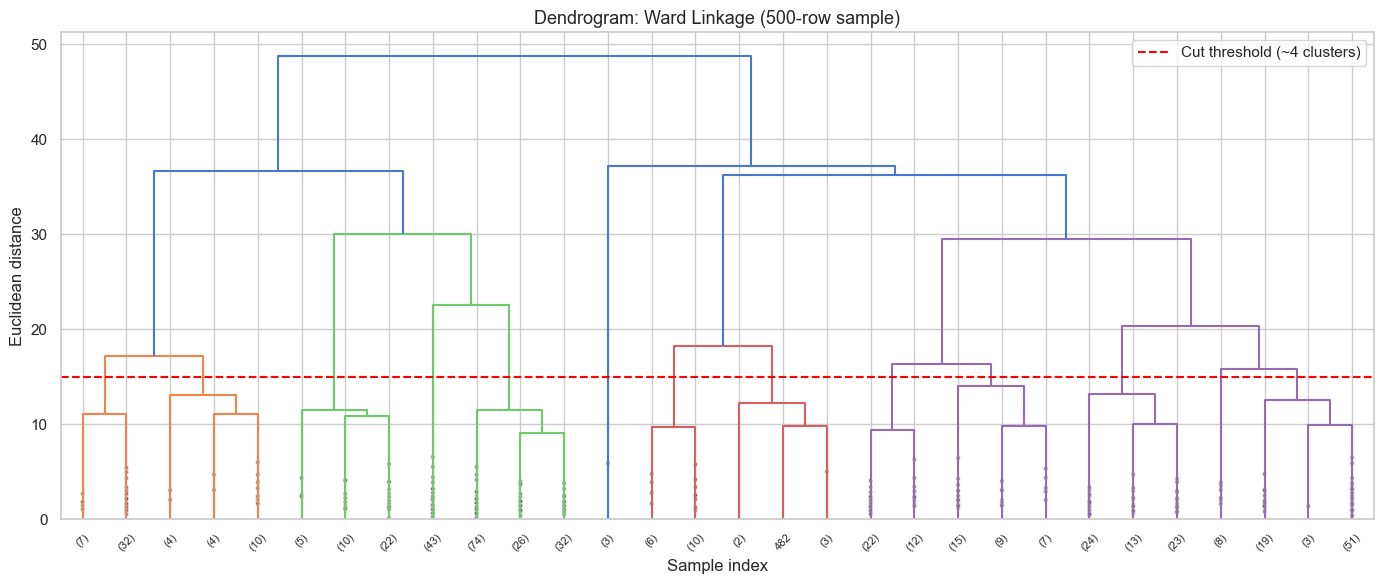

Interpretation: cutting at y=15 suggests ~4 clusters.


In [18]:
# Sample for dendrogram readability (500 rows)
np.random.seed(42)
sample_idx = np.random.choice(len(data_scaled), size=500, replace=False)
data_sample = data_scaled[sample_idx]

# Dendrogram
plt.figure(figsize=(14, 6))
plt.title('Dendrogram: Ward Linkage (500-row sample)', fontsize=13)
plt.xlabel('Sample index')
plt.ylabel('Euclidean distance')

linkage_matrix = shc.linkage(data_sample, method='ward')
dend = shc.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,
    leaf_rotation=45,
    leaf_font_size=8,
    show_contracted=True
)

# Draw a cut line, the longest vertical line without crossing a horizontal bar
# suggests the optimal number of clusters
plt.axhline(y=15, color='red', linestyle='--', label='Cut threshold (~4 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

print('Interpretation: cutting at y=15 suggests ~4 clusters.')

In [19]:
# Note: set to 4 here as suggested by the dendrogram;
# K-Means evaluation later confirms k=3 as the better fit
agg_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agg_labels = agg_cluster.fit_predict(data_scaled)

print('Agglomerative cluster label counts:')
unique, counts = np.unique(agg_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers ({c/len(agg_labels)*100:.1f}%)')

Agglomerative cluster label counts:
  Cluster 0: 4875 customers (54.5%)
  Cluster 1: 300 customers (3.4%)
  Cluster 2: 1194 customers (13.3%)
  Cluster 3: 2581 customers (28.8%)


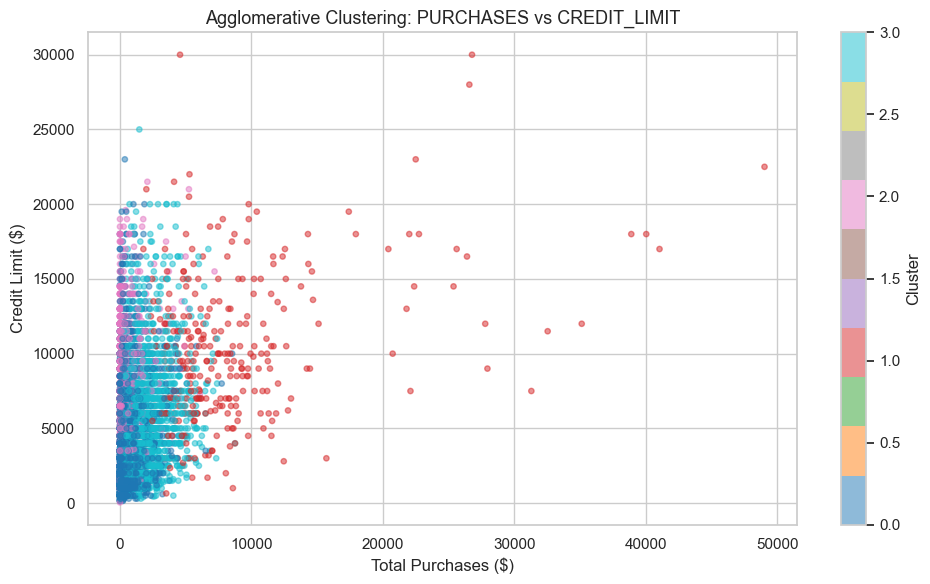

In [20]:
# Visualise Agglomerative clusters: PURCHASES vs CREDIT_LIMIT
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    data_main['PURCHASES'],
    data_main['CREDIT_LIMIT'],
    c=agg_labels,
    cmap='tab10',
    alpha=0.5,
    s=15
)
plt.colorbar(scatter, label='Cluster')
plt.title('Agglomerative Clustering: PURCHASES vs CREDIT_LIMIT', fontsize=13)
plt.xlabel('Total Purchases ($)')
plt.ylabel('Credit Limit ($)')
plt.tight_layout()
plt.show()

---
## 6. K-Means: Finding the Optimal Number of Clusters

We use **two complementary methods**:
- **Elbow method (WCSS):** look for the bend in the inertia curve.
- **Silhouette score:** higher = better-separated clusters (range −1 to 1).

In [21]:
wcss = []
silhouette_scores = []
db_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(data_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, labels, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(data_scaled, labels))

print('k  |   WCSS       | Silhouette | Davies-Bouldin')
print('-' * 52)
for k, w, s, d in zip(K_range, wcss, silhouette_scores, db_scores):
    print(f'{k:2d} | {w:12,.0f} | {s:10.4f} | {d:.4f}')

k  |   WCSS       | Silhouette | Davies-Bouldin
----------------------------------------------------
 2 |      127,785 |     0.2143 | 1.9120
 3 |      111,975 |     0.2400 | 1.5920
 4 |       99,062 |     0.1965 | 1.5748
 5 |       91,490 |     0.1932 | 1.5492
 6 |       84,827 |     0.2038 | 1.5064
 7 |       79,856 |     0.2100 | 1.4918
 8 |       74,485 |     0.2233 | 1.3697
 9 |       69,829 |     0.2255 | 1.2943
10 |       66,466 |     0.2203 | 1.3631


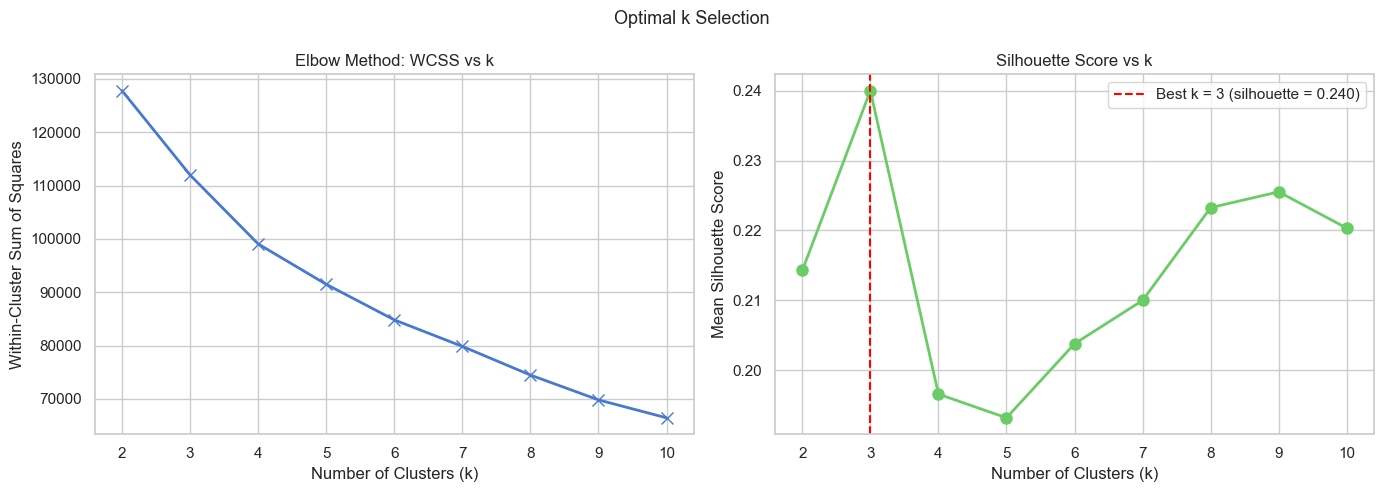


Best k by silhouette score: 3


In [22]:
# Plot Elbow + Silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, wcss, 'bx-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method: WCSS vs k', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='red', linestyle='--',
                label=f'Best k = {best_k} (silhouette = {max(silhouette_scores):.3f})')
axes[1].set_title('Silhouette Score vs k', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

plt.suptitle('Optimal k Selection', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nBest k by silhouette score: {best_k}')

Although the dendrogram suggests approximately 4 clusters, the K-Means evaluation results show that k=3 gives the highest silhouette score. Therefore, the final K-Means model uses 3 clusters because it provides the best separation among the tested values.

---
## 7. Final K-Means Model & Cluster Visualisation

In [23]:
# Train final model with the best k
OPTIMAL_K = best_k  # determined objectively above

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(data_scaled)

# Attach cluster labels back to the original (unscaled) dataframe
df['CLUSTER'] = cluster_labels
data_main['CLUSTER'] = cluster_labels

sil = silhouette_score(data_scaled, cluster_labels, sample_size=3000, random_state=42)
print(f'Final model  |  k={OPTIMAL_K}  |  Silhouette={sil:.4f}')
print()
print('Cluster sizes:')
print(df['CLUSTER'].value_counts().sort_index())

Final model  |  k=3  |  Silhouette=0.2400

Cluster sizes:
CLUSTER
0    1275
1    6114
2    1561
Name: count, dtype: int64


The final silhouette score is 0.2400, which suggests that the clusters are moderately separated rather than strongly distinct. Therefore, the segmentation should be treated as an exploratory customer grouping rather than a perfect separation of customer types.

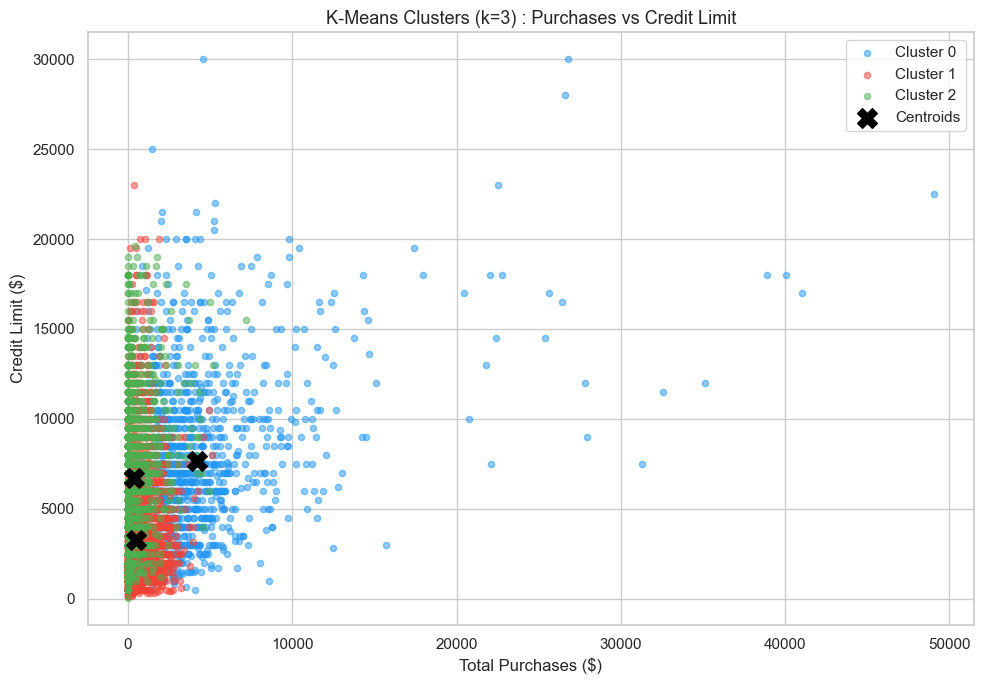

In [24]:
# Visualizing the Clusters

# Scatter: PURCHASES vs CREDIT_LIMIT (same axes as original notebook)
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

plt.figure(figsize=(10, 7))
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    plt.scatter(
        data_main.loc[mask, 'PURCHASES'],
        data_main.loc[mask, 'CREDIT_LIMIT'],
        s=20, alpha=0.5,
        color=colors[c],
        label=f'Cluster {c}'
    )

# Plot centroids in original (unscaled) space via inverse-transform
centers_unscaled = scaler.inverse_transform(kmeans_final.cluster_centers_)
feature_cols = [col for col in data_main.columns if col != 'CLUSTER']
centers_df = pd.DataFrame(centers_unscaled, columns=feature_cols)
plt.scatter(
    centers_df['PURCHASES'],
    centers_df['CREDIT_LIMIT'],
    s=200, c='black', marker='X', zorder=5, label='Centroids'
)

plt.title(f'K-Means Clusters (k={OPTIMAL_K}) : Purchases vs Credit Limit', fontsize=13)
plt.xlabel('Total Purchases ($)')
plt.ylabel('Credit Limit ($)')
plt.legend()
plt.tight_layout()
plt.show()

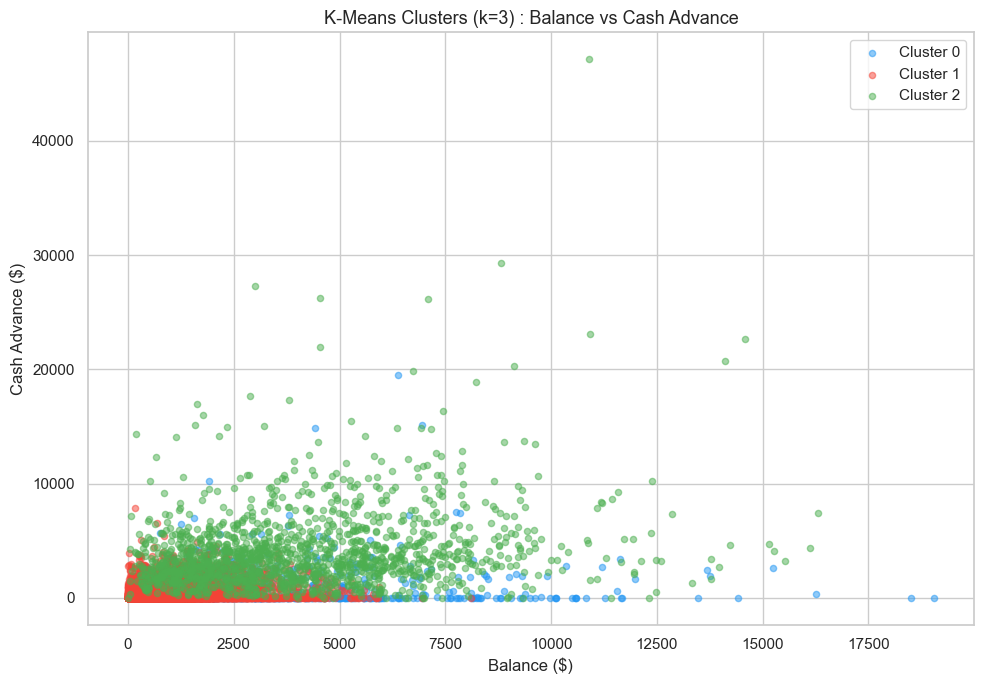

In [25]:
# Additional scatter: BALANCE vs CASH_ADVANCE
plt.figure(figsize=(10, 7))
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    plt.scatter(
        data_main.loc[mask, 'BALANCE'],
        data_main.loc[mask, 'CASH_ADVANCE'],
        s=20, alpha=0.5,
        color=colors[c],
        label=f'Cluster {c}'
    )

plt.title(f'K-Means Clusters (k={OPTIMAL_K}) : Balance vs Cash Advance', fontsize=13)
plt.xlabel('Balance ($)')
plt.ylabel('Cash Advance ($)')
plt.legend()
plt.tight_layout()
plt.show()

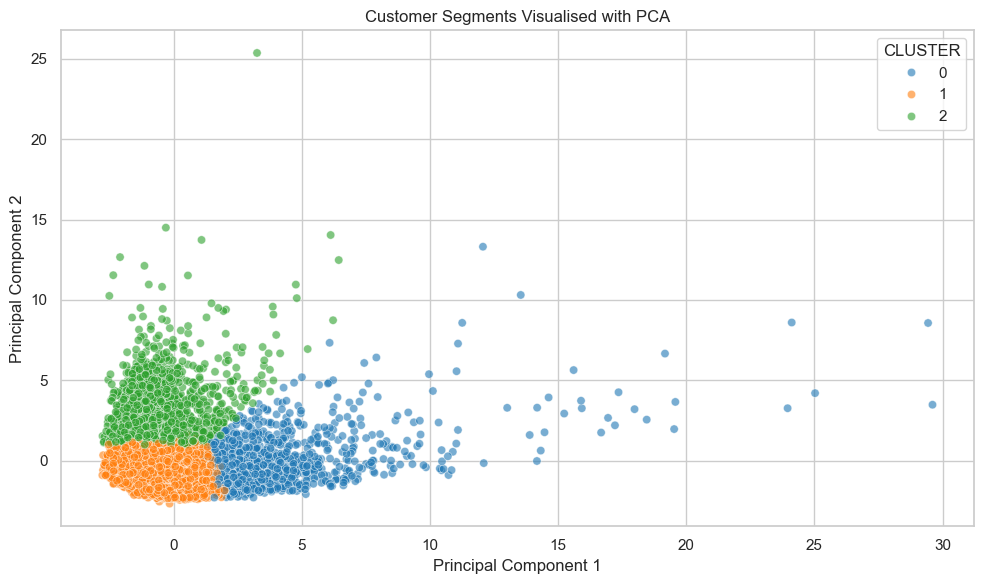

In [26]:
# Reduce scaled data to two principal components for visualising clusters
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["CLUSTER"] = cluster_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="CLUSTER",
    palette="tab10",
    alpha=0.6
)

plt.title("Customer Segments Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

---
## 8. Cluster Profiling & Interpretation

After fitting the model, we summarise each cluster's mean values and assign a business label.

In [27]:
# Mean profile per cluster
profile_cols = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
    'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'TENURE'
]

cluster_profile = df.groupby('CLUSTER')[profile_cols].mean().round(2)
cluster_profile['SIZE'] = df['CLUSTER'].value_counts().sort_index()
cluster_profile['SIZE_%'] = (cluster_profile['SIZE'] / len(df) * 100).round(1)

cluster_profile.style.background_gradient(cmap='RdYlGn', axis=0)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE,SIZE,SIZE_%
CLUSTER,,,,,,,,,,,,
0,2182.350000,4187.020000,449.750000,7642.780000,4075.530000,1227.920000,0.300000,0.950000,0.060000,11.920000,1275,14.200000
1,807.720000,496.060000,339.000000,3267.020000,907.450000,530.070000,0.150000,0.460000,0.070000,11.480000,6114,68.300000
2,4023.790000,389.050000,3917.250000,6729.470000,3053.940000,1765.200000,0.030000,0.230000,0.450000,11.350000,1561,17.400000


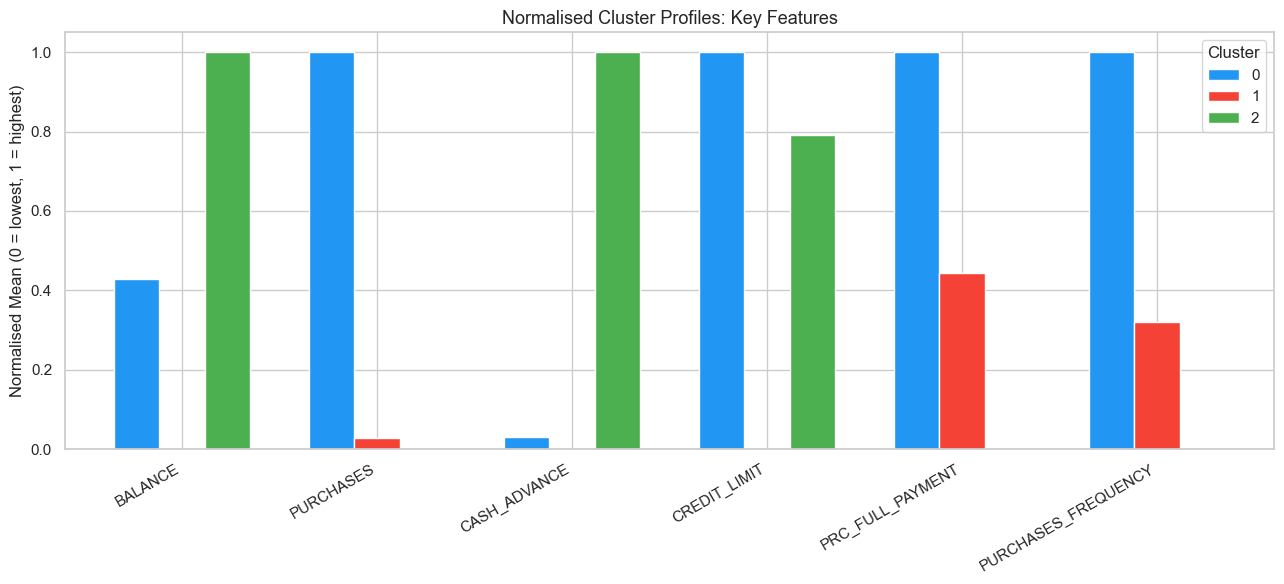

In [28]:
# Radar / bar chart of normalised cluster means
key_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY'
]

# Normalise each feature to 0-1 for comparability on the same chart
profile_norm = cluster_profile[key_features].copy()
for col in key_features:
    col_range = profile_norm[col].max() - profile_norm[col].min()
    if col_range > 0:
        profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / col_range

ax = profile_norm.T.plot(
    kind='bar',
    figsize=(13, 6),
    color=colors[:OPTIMAL_K],
    edgecolor='white',
    width=0.7
)
ax.set_title('Normalised Cluster Profiles: Key Features', fontsize=13)
ax.set_ylabel('Normalised Mean (0 = lowest, 1 = highest)')
ax.set_xticklabels(key_features, rotation=30, ha='right')
ax.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()

In [29]:
# Assign descriptive labels based on cluster_profile output above
# Adjust the keys (0, 1, 2...) to match your actual cluster numbers

label_map = {
    0: 'High-Value Active Purchasers',
    1: 'Low-to-Moderate Activity Users',
    2: 'Cash-Advance Users',
}

df['CLUSTER_LABEL'] = df['CLUSTER'].map(label_map)
print(df['CLUSTER_LABEL'].value_counts())

CLUSTER_LABEL
Low-to-Moderate Activity Users    6114
Cash-Advance Users                1561
High-Value Active Purchasers      1275
Name: count, dtype: int64


## Cluster Interpretation

| Cluster | Label | Size | Key Traits |
|---------|-------|------|------------|
| 0 | **High-Value Active Purchasers** | 14.2% | Highest purchase amount, high credit limit, frequent purchases, and strong payment activity. These customers are highly engaged and valuable. |
| 1 | **Low-to-Moderate Activity Users** | 68.3% | Lower balances, lower purchases, lower payments, and moderate purchase frequency. This is the largest group and may need engagement-focused offers. |
| 2 | **Cash-Advance Users** | 17.4% | Highest cash advance usage, high balances, low purchase activity, and very low full-payment rate. This group may require credit risk monitoring. |

### Marketing Recommendations

- **High-Value Active Purchasers**: offer cashback, loyalty rewards, premium card upgrades, or personalised spending offers.
- **Low-to-Moderate Activity Users**: use engagement campaigns, spending incentives, and targeted product education to increase card usage.
- **Cash-Advance Users**: monitor credit risk, review credit exposure, and offer responsible borrowing support or repayment plans.

## Conclusion

This project used unsupervised learning to segment credit card customers based on their financial behaviour. After comparing different values of k using the elbow method, silhouette score, and Davies-Bouldin score, the final K-Means model selected three customer segments.

The segments identified were High-Value Active Purchasers, Low-to-Moderate Activity Users, and Cash-Advance Users. These groups can support targeted marketing, customer engagement, and credit risk monitoring.

The clustering result should be treated as an exploratory segmentation because the silhouette score indicates moderate separation between groups.